In [1]:
#import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_score,recall_score, f1_score,accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
#load the model
df = pd.read_csv("heart.csv")

In [3]:
#basic info
df.columns
df.info()
df["target"].nunique()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
#drop column from testing
x = df.drop("target", axis = 1)
y = df["target"]

In [5]:
x.head()
y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [6]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,random_state = 42)
y_train[y_train == 1]
y_train[y_train == 0]

202    0
196    0
176    0
177    0
258    0
      ..
257    0
214    0
302    0
188    0
270    0
Name: target, Length: 109, dtype: int64

In [7]:
#scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Model 1 LogisticRegression

In [8]:
#model 
model = LogisticRegression(max_iter = 1000)
model.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [9]:
y_pred = model.predict(x_test_scaled)
y_pred

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [10]:
cm = confusion_matrix(y_test,y_pred)
cr = classification_report(y_test,y_pred)
ps = precision_score(y_test,y_pred)
rs = recall_score(y_test,y_pred)
fs = f1_score(y_test,y_pred)
print("confusion_matrix",cm)
print("classification_report",cr)
print("precision_score",ps)
print("recall_score",rs)
print("f1_score",fs)

confusion_matrix [[25  4]
 [ 5 27]]
classification_report               precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

precision_score 0.8709677419354839
recall_score 0.84375
f1_score 0.8571428571428571


In [11]:
#cross validation for hyperparametertuning using gridsearchcv
log_model = LogisticRegression(max_iter = 1000)
param_grid = {
    "C" : [0.01,0.1,1,10],
    "penalty": ["l2"] 
}
log_cv = GridSearchCV(
    log_model,
    param_grid,
    cv = 5
)
log_cv.fit(x_train, y_train)
y_pred = log_cv.predict(x_test)
print("Recall:", recall_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

print(log_cv.best_params_)

Recall: 0.84375
Accuracy: 0.8524590163934426
Precision: 0.8709677419354839
{'C': 10, 'penalty': 'l2'}


In [12]:
#store results 
results = {}

In [13]:
results["Logistic Regression (Tuned)"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Best Params": log_cv.best_params_
}

In [14]:
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Best Params,Precision,Recall
Logistic Regression (Tuned),0.852459,"{'C': 10, 'penalty': 'l2'}",0.870968,0.84375


Model 2 – Gaussian Naive Bayes

In [15]:
#gaussian based model
gnb_model = GaussianNB()
gnb_model.fit(x_train_scaled,y_train)

GaussianNB()

In [16]:
y_pred = gnb_model.predict(x_test_scaled)

In [17]:
#evaluation
print("accuracy",accuracy_score(y_test, y_pred))
print("reacll",recall_score(y_test, y_pred))
print("precision",precision_score(y_test, y_pred))
      

accuracy 0.8688524590163934
reacll 0.84375
precision 0.9


In [18]:
#cross validation for hyperparametertuning using gridsearchcv
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()

param_grid = {
    "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
}
Nb_cv = GridSearchCV(
    gnb_model,
    param_grid,
    cv=5
)
Nb_cv.fit(x_train_scaled, y_train)

# Predict using best model
y_pred = Nb_cv.predict(x_test_scaled)

print("Recall:", recall_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

print("Best Params:", Nb_cv.best_params_)

Recall: 0.84375
Accuracy: 0.8688524590163934
Precision: 0.9
Best Params: {'var_smoothing': 1e-09}


In [19]:
#store results
results["GaussianNaiveBayes (Tuned)"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Best Params": Nb_cv.best_params_
}

In [20]:
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Recall,Precision,Best Params
Logistic Regression (Tuned),0.852459,0.84375,0.870968,"{'C': 10, 'penalty': 'l2'}"
GaussianNaiveBayes (Tuned),0.868852,0.84375,0.9,{'var_smoothing': 1e-09}


Model 3 – KNN

In [21]:
#knn model
knn_classifier = KNeighborsClassifier(n_neighbors = 7)
knn_classifier.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=7)

In [22]:
y_pred = knn_classifier.predict(x_test_scaled)

In [23]:
print("recall_score",recall_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("precision_score",precision_score(y_test,y_pred))


recall_score 0.90625
accuracy_score 0.9180327868852459
precision_score 0.9354838709677419


In [24]:
#cross validation for hyperparametertuning using gridsearchcv
from sklearn.model_selection import GridSearchCV
classifier = KNeighborsClassifier()
param_grid = {"n_neighbors":[3,5,7,9]}

classifierCV = GridSearchCV(
    classifier,
    param_grid,
    cv=5
)
classifierCV.fit(x_train_scaled, y_train)
y_pred = classifierCV.predict(x_test_scaled)

print("recall_score",recall_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("precision_score",precision_score(y_test,y_pred))

#results 
res = pd.DataFrame(classifierCV.cv_results_)
print(res[["param_n_neighbors","mean_test_score"]])
print(classifierCV.best_params_)

recall_score 0.875
accuracy_score 0.9016393442622951
precision_score 0.9333333333333333
  param_n_neighbors  mean_test_score
0                 3         0.805782
1                 5         0.814116
2                 7         0.801616
3                 9         0.801786
{'n_neighbors': 5}


In [25]:
results["KNN (Tuned)"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Best Params": classifierCV.best_params_
}

In [26]:
results_df = pd.DataFrame(results).T
results_df

,Accuracy,Recall,Precision,Best Params
Logistic Regression (Tuned),0.852459,0.84375,0.870968,"{'C': 10, 'penalty': 'l2'}"
GaussianNaiveBayes (Tuned),0.868852,0.84375,0.9,{'var_smoothing': 1e-09}
KNN (Tuned),0.901639,0.875,0.933333,{'n_neighbors': 5}


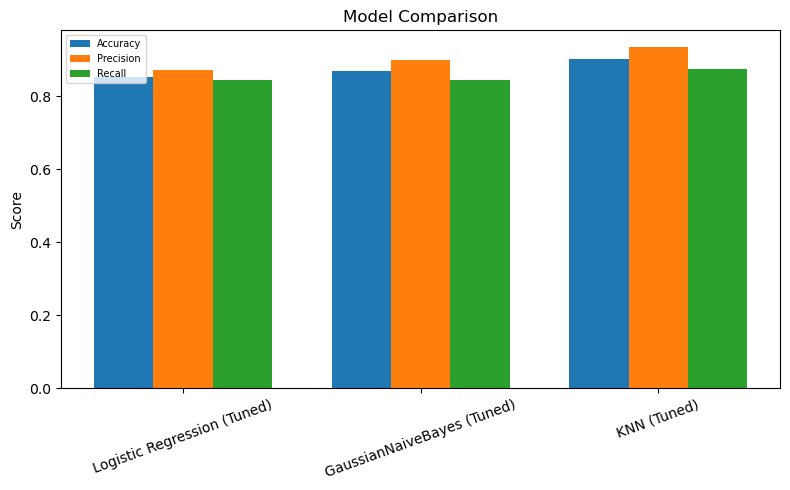

In [27]:
import matplotlib.pyplot as plt
import numpy as np

models = results_df.index
accuracy = results_df["Accuracy"]
precision = results_df["Precision"]
recall = results_df["Recall"]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5)) 
plt.bar(x - width, accuracy, width, label="Accuracy")
plt.bar(x, precision, width, label="Precision")
plt.bar(x + width, recall, width, label="Recall")

plt.xticks(x, models, rotation=20)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend(loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

In [30]:
import os
os.getcwd()

'C:\\Users\\tanvi\\Desktop\\PrimeBatch'